In [2]:
from Scope.Read_Write import load_binary

In [30]:
## Loads the System object from a binary file, provided in the tutorial folder
sys = load_binary('./Sources/ABITEM.npy')
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE SCO-System Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Name                  = ABITEM
 Source Path           = /Users/sergivela/Documents/SCOPE/Database_SCO/4-Merged/ABITEM/
 Calculations Path     = /Users/sergivela/Documents/SCOPE/Database_SCO/Test_V1/Calcs/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Database_SCO/Test_V1/Systems/ABITEM/

 # of Sources          = 6
     idx, type, name, formula               
     0: cell ABITEM01 H104-C92-N24-O4-S8-Fe4 
     1: cell ABITEM H104-C92-N24-O4-S8-Fe4 
     2: cell ref_hs_cell H104-C92-N24-O4-S8-Fe4 
     3: cell ref_ls_cell H104-C92-N24-O4-S8-Fe4 
     4: specie ref_hs_mol H18-C20-N6-S2-Fe 
     5: specie ref_ls_mol H18-C20-N6-S2-Fe 




In [4]:
#The System Object mainly stores paths and sources. 

# What are Sources? A source is a chemical entity. There are two main types of sources: CELLs and SPECIEs:  
# -The difference between CELLs and SPECIEs is that the former is a periodic structure, so it must include cell parameters.  
# -A SPECIE is a class with various subclasses: Molecule, Ligand, and Group. Ligands and Groups only appear in Transition Metal Complexes.

# We will navigate both Objects below.

## Sources 1: The CELL Class


In [5]:
cell = sys.sources[0]
print(cell)

-----------------------------------
-- >>> SCOPE SCO-CELL Object >>> --
-----------------------------------
 Version               = 1.0
 Type                  = cell
 Name                  = ABITEM01
 Num Atoms             = 236
 Cell Parameters a:c   = [12.134, 11.987, 16.925]
 Cell Parameters al:ga = [90.0, 90.137, 90.0]
 # Molecules:          = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 # of Ref Molecules:   = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 
 Phase                 = LS
 HS Molar Fraction     = 0.0




In [6]:
# Have a look at the CELL object above. The key information is displayed, some other is accessible as attributes:

# -It has 236 atoms, whose coordinates are stored as cell.coord, and labels as cell.labels.
print("Labels and Coordinates:", cell.labels[0], cell.coord[0]) 
# -It has cell parameters, stored as cell.cell_param
print("Cell Parameters:", cell.cell_param)
# -It has 8 Molecules, stored inside cell.moleclist
print("Number of Molecules:", len(cell.moleclist))
# -It has 2 types of molecules, with formulae:
for mol in cell.refmoleclist:
    print("Unique Molecule Formula:", mol.formula)

Labels and Coordinates: Fe [4.2094449, 7.7086, 4.1449207]
Cell Parameters: [12.134, 11.987, 16.925, 90.0, 90.137, 90.0]
Number of Molecules: 8
Unique Molecule Formula: H18-C20-N6-S2-Fe
Unique Molecule Formula: H8-C3-O


In [7]:
# You can also run CELL-class functions, like cell.check_fragmentation(), which checks if any molecule appears fragmented due to how the cell is cut
cell.check_fragmentation()

False

In [8]:
# You can also view the unit cell with cell.view(), which opens a 3D viewer
cell.view(size='large')

## Sources 2: The SPECIE Class

In [9]:
# Hopefully, you can identify the 4 transition metal complexes (TMCs) and the 4 solvent molecules in the viewer above.
# In any case, you can access those molecules through the cell.moleclist attribute. Taking the first molecule as an example:
mol = cell.moleclist[0]
# Again, the key information is displayed. The rest is accessible as attributes
print(mol)


--------------------------------------------------
------------- SCOPE MOLECULE Object --------------
--------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Number of Parents     = 1
 Total Charge          = 0
 SMILES                = ['[N-]=C=S', '[H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]', '[N-]=C=S']
 Has Adjacency Matrix  = YES
 Has Bonds             = YES
 # Ligands             = 3
 # Metals              = 1




In [10]:
# Notice the molecule is of type=SPECIE, and subtype=MOLECULE. Molecules are subclasses of SPECIEs. 
# Also, this molecule is a TMC, as shown by:
print(mol.iscomplex)
# As a result, it has a ligand list (mol.ligands), which contains 3 Ligand objects:
print(len(mol.ligands), "ligands in this TMC")
# And a list of metal atoms:
print(len(mol.metals), "metal atom(s) in this TMC")

True
3 ligands in this TMC
1 metal atom(s) in this TMC


In [11]:
## Apart from attributes, species -and thus also molecules- also have useful functions, e.g.:
print(mol.get_centroid())

[3.6909978851063827, 7.193013587234044, 4.575682280851063]


In [12]:
## All species can be visualized with the .view() method:
mol.view()

In [13]:
## You can access the metal and ligand objects as:
met = mol.metals[0]
print(met)
lig = mol.ligands[0]
print(lig)

-----------------------------------------------
------------- SCOPE METAL Object --------------
-----------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Atom Charge                  = 2
 Metal Adjacency (madjnum)    = 6
 Regular Adjacencies (adjnum) = 6


------------------------------------------------
------------- SCOPE LIGAND Object --------------
------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = ligand
 Number of Atoms       = 3
 Formula               = C-N-S
 Number of Parents     = 2
 Total Charge          = -1
 SMILES                = [N-]=C=S
 Has Adjacency Matrix  = NO 
 Has Bonds             = YES
 # HAS RDKIT OBJECT    = YES




In [14]:
## The METAL is a subclass of ATOM (type=atom, subtype=metal). Apart from attributes, it also has useful functions, e.g.:
met.get_cshm()   ## This one retrieves the Coordination Shape Measure of the metal.
                 ## The CShM quantifies how close the coordination environment is to an ideal geometry, which is an octahedron by default.

0.4513435606013805

In [15]:
## The LIGAND is also a subclass of SPECIE (type=specie, subtype=ligand). It has some useful functions too, e.g.:
print(lig.get_denticity())
## This one retreives the atom object of all atoms that are connected to a metal, in this case only an N atom:
print(lig.get_connected_atoms())

1
[------------------------------------------------
------------- SCOPE ATOM Object ----------------
------------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = atom
 Label                        = N
 Atomic Number                = 7
 Atom Charge                  = 0
 Metal Adjacency (madjnum)    = 1
 Regular Adjacencies (adjnum) = 2

]


In [16]:
## So far, we went down in the hierarchy: System -> Cell -> Molecule -> Metal/Ligand. You can also go back up:
parent = lig.get_parent('cell') # This retrieves the parent CELL object of the ligand
print(parent)

-------------------------------
   >>> SCOPE CELL Object >>>   
-------------------------------
 Version               = 1.0
 Type                  = cell
 Name                  = ABITEM01
 Num Atoms             = 236
 Cell Parameters a:c   = [12.134, 11.987, 16.925]
 Cell Parameters al:ga = [90.0, 90.137, 90.0]
 # Molecules:          = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 # of Ref Molecules:   = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 




In [17]:
idx = lig.get_parent_indices('molecule') # This retrieves the index of the ligand atoms in the parent molecule
print(idx)

[2, 7, 41]


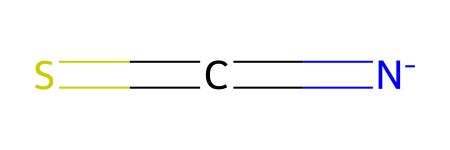

In [18]:
## The cell in the example were imported from cell2mol CELL objects. Ligands in these cells are associated with an rdkit object:
lig.rdkit_obj

In [19]:
## And a Smiles
lig.smiles

'[N-]=C=S'

In [20]:
## In transition metal complexes, molecule smiles are the ligand smiles concatenated. New better ways have been proposed, but not yet implemented in SCOPE.
mol.smiles

['[N-]=C=S',
 '[H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]',
 '[N-]=C=S']

## Also, the ATOM and BOND Classes

In [21]:
# As we've briefly seen above, species have atoms. They also have bonds. Both are classes in SCOPE.
len(mol.atoms)

47

In [22]:
## The first atom of the molecule happens to be the metal. The second is a regular atom. Notice the different subtype
for at in mol.atoms[0:10]:                                  ## Printing the first 10 atoms
    print(at.get_parent_index('molecule'), at.label, at.subtype, at.charge, at.madjnum, at.adjnum)

## at.charge stores the formal atomic charge.
## at.madjnum is the number of adjacencies the atom has with a metal center.
## at.adjnum is the total number of adjacencies the atom has with any other atom

0 Fe metal 2 6 6
1 S atom 0 0 1
2 S atom 0 0 1
3 N atom 0 1 3
4 N atom 0 1 3
5 N atom 0 1 3
6 N atom 0 1 4
7 N atom 0 1 2
8 N atom 0 1 2
9 C atom 0 0 3


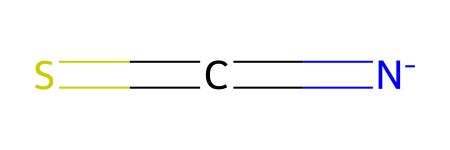

In [29]:
lig.rdkit_obj    

In [23]:
## Bonds are also stored as objects, with very limited functionality for now:
at = mol.atoms[1]
print(at.bonds)

## The formal bond order (bond.order) comes from the rdkit object, if available:

[----------------------------------------------
------------- SCOPE BOND Object --------------
----------------------------------------------
 Version                 = 1.0
 Type                    = bond
 Atom1 Index in Molecule = 1
 Atom2 Index in Molecule = 42
 Label Atom1             = S
 Label Atom2             = C
 Formal Bond Order       = 3.0
 Distance                = 1.65

]
